# CSE2530 Computational Intelligence
## Assignment 2: Artificial Neural Networks


    
|    Group   |           1          |
|------------|----------------------|
| Junhan Chong  |        6153283       |
| Jack Bergmann  |        6200850       |
| Madhav Tiwari  |        6141870       |
| Ben Chen  |        6543405       |

</div>

#### Imports

In [4]:
# You may only use numpy to implement your neural network
# You are not allowed to use scikit-learn, other than for Section 1.6.
# You are also not allowed to use Pytorch, Tensorflow, and similar machine learning frameworks.
# You can make use of any other libraries for miscellaneous functions, e.g. to create the visual aids.

# Put all of your imports in this code block
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

#### Loading the data

In [5]:
features = np.genfromtxt("../data/features.txt", delimiter=",")
targets = np.genfromtxt("../data/targets.txt", delimiter=",")
unknown = np.genfromtxt("../data/unknown.txt", delimiter=",")

np.random.seed(14)

# Create a random order of indices from 0 (inclusive) to N (exclusive)
N = features.shape[0]
perm = np.random.permutation(N)

# order the data according to the permutation
features = features[perm]
targets = targets[perm]

# 70:15:15 split of data (train/validation/test)
train_ratio = 0.7
val_ratio = 0.15

train_end = int(train_ratio * N)
val_end = int((train_ratio + val_ratio) * N)

# Training set
train_x = features[:train_end]
train_y = targets[:train_end]

# Validation set
val_x = features[train_end:val_end]
val_y = targets[train_end:val_end]

# Test set
test_x = features[val_end:]
test_y = targets[val_end:]

## 1 Questions
### 1.2 Architecture
#### Question 1:

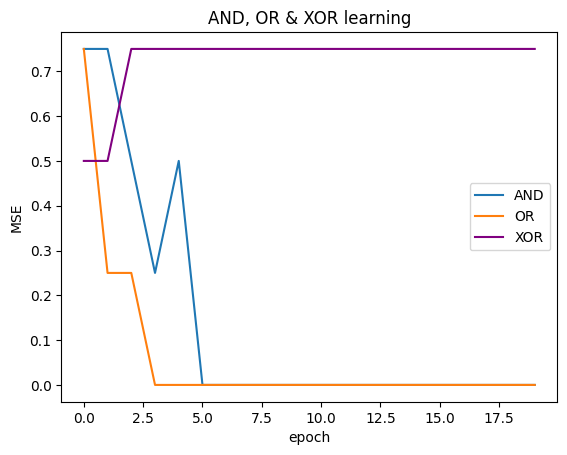

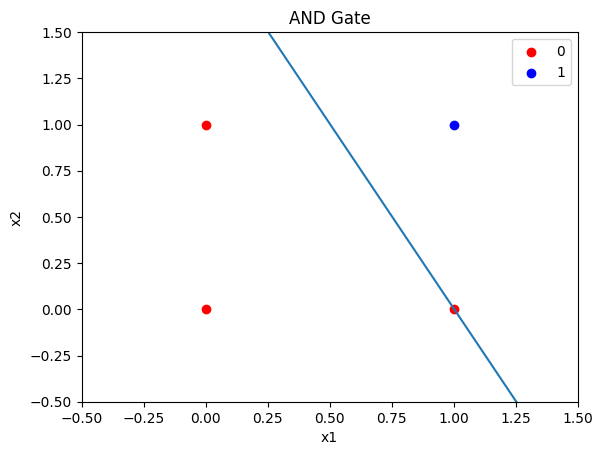

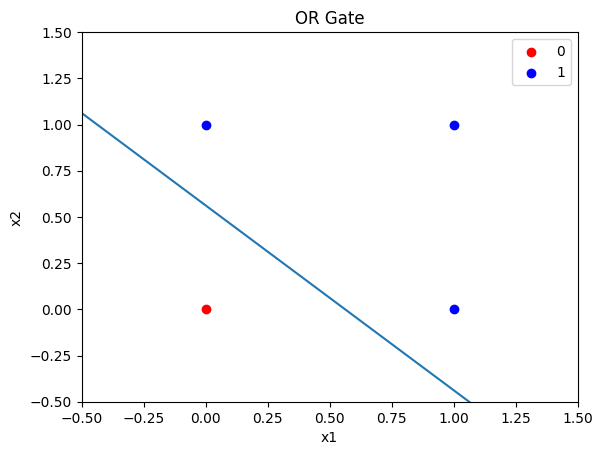

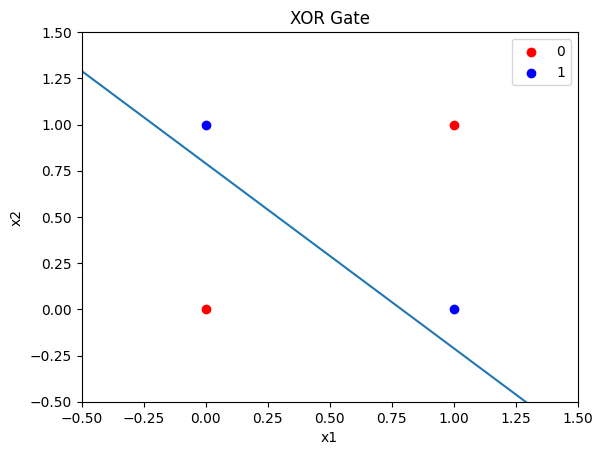

In [6]:
class Perceptron:
    def __init__(self, num_features):
        self.num_features = num_features
        self.weights = np.zeros(num_features)
        self.bias = np.random.randn()
        self.a = 0.1
    
    # Step activation
    def step(self, x):
        # f(x) = 1 if wx + b  >= 0, else 0
        return np.where(x @ self.weights + self.bias >= 0, 1, 0)
    
    # Perceptron learning
    def train(self, x_train, y_train, epochs):
        # initialise error array to return later
        errors = np.zeros(epochs)
        for i in range(epochs):
            # Using MSE
            error = np.mean(np.pow(self.step(x_train) - y_train, 2))
            errors[i] = error
            for xi, yi in zip(x_train, y_train):
                pred = self.step(xi)
                if pred != yi:
                    # Update weights and bias only when misclassified
                    error = yi - pred
                    self.weights += self.a * error * xi
                    self.bias += self.a * error
        return errors
    
# plotting functions
# plots the samples and the regression line separating the samples
def plot_gate(X, y, weights, bias, title):
    plt.figure()
    
    class0 = X[y == 0]
    class1 = X[y == 1]
    
    plt.scatter(class0[:,0], class0[:,1], c = 'r', label = "0")
    plt.scatter(class1[:,0], class1[:,1], c = 'b', label = "1")
    plt.legend()
    
    if weights[1] != 0:
        x_vals = np.linspace(-0.5, 1.5, 100)
        y_vals = -(weights[0] * x_vals + bias) / weights[1]
        plt.plot(x_vals, y_vals)
    
    plt.xlim(-0.5, 1.5)
    plt.ylim(-0.5, 1.5)
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()



train_x_perp = np.array([[0,0], [0,1], [1,0], [1,1]])

# AND
and_perceptron = Perceptron(2)
y_and = np.array([0, 0, 0, 1])
and_errors = and_perceptron.train(train_x_perp, y_and, 20)

# OR
or_perceptron = Perceptron(2)
y_or = np.array([0, 1, 1, 1])
or_errors = or_perceptron.train(train_x_perp, y_or, 20)

# XOR
xor_perceptron = Perceptron(2)
y_xor = np.array([0, 1, 1, 0])
xor_errors = xor_perceptron.train(train_x_perp, y_xor, 20)

# Plotting losses over epochs for the three gates
plt.title("AND, OR & XOR learning")
plt.xlabel("epoch")
plt.ylabel("MSE")
plt.plot(and_errors, label = "AND")
plt.plot(or_errors, label = "OR")
plt.plot(xor_errors, label = "XOR", c = "purple")
plt.legend()
plt.show()

plot_gate(train_x_perp, y_and, and_perceptron.weights, and_perceptron.bias, "AND Gate")
plot_gate(train_x_perp, y_or, or_perceptron.weights, or_perceptron.bias, "OR Gate")
plot_gate(train_x_perp, y_xor, xor_perceptron.weights, xor_perceptron.bias, "XOR Gate")


<div>

The perceptron for AND and OR is successfully trained to be able to output the correct values. This is possible because the positive and negative classes are linearly separable. Hence, the error reaches 0 after training.

The regression lines for AND and OR perceptrons doesn't separate the classes with equal amount of padding, which makes sense because once the line separates the classes so that the error is 0, no more updates occur in any of the weights nor the bias.

In contrast, for XOR learning, the error does not reach 0 because the two classes are not linearly separable.


</div>

#### Question 2

<div>

There should be 10 input neurons to take values from the 10 features.

</div>

#### Question 3

<div>

7 output neurons to classify the samples into the 7 possible classes (softmax or argmax)

</div>

#### Question 4

<div>

We think that one hidden layer will suffice to start with. With 6 hidden layers, data is linearly separable so it's illogical. Although two hidden layers also seem to be appropriate, with 10 features, it is faster and more efficient to start with one and gauge the network's performance to decide if it should be increased to two.

As for the number of neurons per layer, there are certain base 20uristics typically followed. One is the geometric mean rule, which balances the input and output size by taking: sqrt(input_size x output_size). The other common heuristics is the 2/3 rule, where you take 2/3 * (input_size + output_size), which is used usually for regression and/or small datasets. The values we obtain from those heuristics for our specific dataset are 8 and 11, respectively. For the same reason as above, we pick 8 to start small and scale accordingly.

</div>

#### Question 5

<div>

The choice of activation function depends on the depth of the neural network, and type of predictions (regression/classification). In genereal, sigmoid function would not be used in the hidden layers, but in our case, since the network won't be too deep, the vanishing gradient problem vanishes (hahaha). And since the sigmoid function is differentiable, we can use the sigmoid function to simplify computation.

</div>

#### Question 6

<div>

![ANN Diagram](../data/ann_diagram.png)

</div>

### 1.3 Training

When coding a neural network from scratch, it helps to think of a layer as an individual component that can be easily combined with other layers. To help you create a modular implementation of a neural network, we provide you with a template for the implementation along with some explanations.

**Note that using the template below is not mandatory. You may choose to modify this template or implement your own version of the neural network altogether. If the latter, please remove our template from the notebook and ensure that it instead includes a complete, fully functional implementation of your own.**

**Linear (fully connected) layer**

A linear or fully connected layer maps the input data to an output by performing a linear transformation, where each input neuron is connected to every output neuron. The forward pass of a linear layer is computed as $y = wx + b$, where $w$ and $b$ are trainable parameters. The gradients of the loss with respect to $w$ and $b$ are defined using the chain rule:

$$\frac{\partial \mathcal{L}}{\partial w}=\frac{\partial \mathcal{L}}{\partial y} \cdot \frac{\partial y}{\partial w}, \quad \frac{\partial \mathcal{L}}{\partial b}=\frac{\partial \mathcal{L}}{\partial y} \cdot \frac{\partial y}{\partial b}, $$

where $\frac{\partial \mathcal{L}}{\partial y}$ is the upstream gradient i.e., the gradient flowing from deeper layers into the current layer, and the other two terms are the local gradients:

$$
\frac{\partial y}{\partial w}=x, \quad \frac{\partial y}{\partial b}=1.
$$

Since $x$ is needed to compute the gradients, we can store (cache) its value during the forward pass. Finally, we need to return a downstream gradient so that more shallow layers can use it as their upstream gradient. The downstream gradient of a layer is simply its upstream gradient multiplied by the local gradient of its output with respect to its input:

$$
\frac{\partial \mathcal{L}}{\partial x}=\frac{\partial \mathcal{L}}{\partial y} \cdot \frac{\partial y}{\partial x}
$$

**Note.** Be aware of how you multiply the arrays, it might be useful to print the shapes of each array and to think about the desired shape of the output.  

In [7]:
class Linear:
    def __init__(self, in_features, out_features, init_method):
        """ 
        Args:
            in_features: number of input features.
            out_features: number of output features.
            init_methods: method for initialising weights and bias

        Contains neurons within a single layer of an ANN. Can be fed inputs with arbitrary size
        """

        # using pattern matching to initialise weights. Weights are of dimension (out_features, in_features), each row containing the weights for one node.
        match init_method:
            # zero initialisation
            case 0:
                self.weight = np.zeros((out_features, in_features))
                self.bias = np.zeros(out_features)
            # normal initialisation
            case 1:
                self.weight = np.random.randn(out_features, in_features)
                self.bias = np.random.randn(out_features)
            # uniform distribution between (inclusive) 0 and 1 (exclusive)
            case 2:
                self.weight = np.random.rand(out_features, in_features)
                self.bias = np.random.rand(out_features)
            # Xavier initialisation, with distribution being uniform over the range
            case 3:
                degree = in_features + out_features
                limit = math.sqrt(3.0 / degree)
                self.weight = np.random.uniform(-limit, limit, size=(out_features, in_features))
                self.bias = np.random.uniform(-limit, limit, size=(out_features))
            # He initialisation, with distribution being uniform over the range
            case 4:
                lower = - math.sqrt(6/in_features)
                upper = math.sqrt(6/out_features)
                self.weight = np.random.uniform(lower, upper, size=(out_features, in_features))
                # biases are often initialised to 0 in He initialisation
                self.bias = np.zeros(out_features)
        

        self.cache = None
        # For storing the gradients w.r.t. the weight and the bias
        self.weight_grad = None
        self.bias_grad = None

        # momentum should have same dimensions as the weights and bias as each weight and bias has its own momentum
        self.v_w = np.zeros_like(self.weight)
        self.v_b = np.zeros_like(self.bias)

    def forward(self, x):
        """ Perform the forward pass of a linear layer. 
        Store (cache) the input so it can be used in the backward pass.

        Args:
            x: input of a linear layer. Shape: (N, in_features)

        Returns: 
            y: output of a linear layer. Shape: (N, out_features)
        """
        self.cache = x
        y = x @ self.weight.T + self.bias
        return y
    
    def backward(self, dupstream):
        """ Perform the backward pass of a linear layer.  

        Args:
            dupstream: upstream gradient. Shape: (N, out_features)

        Returns:
            dx: downstream gradient. Shape: (N, in_features)
        """

        # if momentum isn't initialised, use the first calculation of momentum
        if self.weight_grad is not None:
            self.v_w = self.weight_grad
            self.v_b = self.bias_grad

        self.weight_grad = dupstream.T @ self.cache # dL/dy * dy/dw = dupstream * x
        self.bias_grad = np.sum(dupstream, axis=0) # dL/dy * dy/db = dupstream * 1, each neuron takes the sum of all upstream gradients that it's connected to.
        dx = dupstream @ self.weight
        return dx

**Activation functions**

You also need to implement an activation function suitable for the task at hand.

Think about how to perform the backward pass i.e., what is the local gradient and what the downstream gradient should be. Do not forget to take the upstream gradient into account.

In [8]:
class Activation:
    def __init__(self):
        self.cache = None
    
    def forward(self, x):
        """ Perform a forward pass of your activation function.
        Store (cache) the output so it can be used in the backward pass.

        Args:
            x: input to the activation function. Shape: (N, out_features)

        Returns:
            y: output of the activation function. Shape: (N, out_features)
        """
        y = 1 / (1 + np.exp(-x)) # sigmoid function
        self.cache = y

        return y
    
    def backward(self, dupstream): 
        """ Perform a backward pass of the activation function. 
        Make sure you do not modify the original dupstream.

        Args:
            dupstream: upstream gradient. Shape: (N, out_features), intuition: for N samples, there are 'out_features' numbers of gradients (from next layer)

        Returns:
            dx: downstream gradient. Shape: (N, out_features)
        """
        
        # given the upstream gradient, calculate how much the change in z(x) affects the loss (dL/dZ) = dupstream * dy / dZ, y = sigmoid(x)
        dy_dx = (self.cache * (1 - self.cache))
        dx = dupstream * dy_dx
        return dx

**Network** 

Now that you have implemented a `Linear` layer and an activation function, you can combine them in different ways and have the `Network` class perform forward and backward passes through all layer of the network in the specified order.

Additionally, you should make the `Network` class update all the trainable parameters of the network in `optimizer_step`.

In [9]:
class Network:
    def __init__(self, layer_dimensions, init_method):
        """ Initialisation function

        Parameters:
            layer_dimensions: list containing number of neurons per layer. eg. [10, 8, 7] would be input layer with 10 neurons, hidden layer with 8, then output layer with 7
            init_method: the initialisation method to use within the Linear layer Options 0-4
        
        """
        self.layers = []
        for i in range(len(layer_dimensions) - 1):
            # create a new layer, with in_features as current index and out_features as next in the list (next layer)
            l = Linear(
                layer_dimensions[i],
                layer_dimensions[i+1],
                init_method
            )
            self.layers.append(l)

            # Add an activation layer between two linear layers. Not after last Linear layer as that will be the softmax function.
            if i < len(layer_dimensions) - 2:
                self.layers.append(Activation())

    def forward(self, x):
        """ Perform a forward pass over the entire network.

        Args:
            x: input data. Shape: (N, features)

        Returns:
            y: predictions. Shape: (N, classes)
        """
        for l in self.layers:
            x = l.forward(x)
        return x
    
    def backward(self, dupstream):
        """ Perform a backward pass over the entire network.

        Args:
            dupstream: upstream gradient. Shape: (N, classes))

        Returns:
            dx: downstream gradient. Shape: (N, features)
        """
        for l in reversed(self.layers):
            dupstream = l.backward(dupstream)
        return dupstream
    
    def optimizer_step(self, lr, beta):
        """ Calculate momentum
            Update the weight and bias parameters of each layer using momentum

        Args:
            lr: learning rate.
        """
        
        for l in self.layers:
            # if the layer is a Linear layer, update using momentum and current gradient
            if isinstance(l, Linear):
                # update momentum
                l.v_w = beta * l.v_w + (1 - beta) * l.weight_grad
                l.v_b = beta * l.v_b + (1 - beta) * l.bias_grad
                # update weights and biases
                l.weight -= lr * l.v_w
                l.bias -= lr * l.v_b

**Loss function**

You also need to implement a loss function that will measure how well your neural network performs at the task.

In [17]:
def Loss(y_true, y_pred):
    """ Computes the value of the loss function and its gradient.  

    Args:
        y_true: ground truth labels. Shape: (N, classes)
        y_pred: predicted labels. Shape: (N, classes)

    Returns:
        loss: value of the loss. 
        grad: gradient of loss with respect to the predictions. Shape: (N, classes)
    """
    N = y_true.shape[0]

    # transform output values to e^(-y_hat) after translating the values to be all negative.
    y_exp = np.exp(y_pred - np.max(y_pred, axis = 1, keepdims = True))
    # turn into probablities (softmax)
    y_probs = y_exp / np.sum(y_exp, axis = 1, keepdims = True) # collapse the columns

    # since y_true is going to be just a single value, we can use the value as index to find the corresponding probability
    pred_correct_prob = y_probs[np.arange(N), y_true.astype(int) - 1]
    # must add a tiny value to the probability in the case that it's 0, as the log of 0 is negative infinity.
    eps = 1e-10
    loss = -np.mean(np.log(np.clip(pred_correct_prob, eps, 1.0)))
    # Create a matrix with same shape as y_pred, but turned to 0s and 1s according to predicted probabilities.
    one_hot = np.zeros_like(y_probs)
    one_hot[np.arange(N), y_true.astype(int) - 1] = 1

    # gradient formula for dL/dy_hat = y_hat - true / N
    grad = (y_probs - one_hot) / N
    
    return (loss, grad)

**Training loop**

Finally, define a training loop in which for each optimizer step you:

1. Obtain the predictions by performing a forward pass of the network;

2. Compute the loss and its gradient by comparing the predictions with the ground truth according to the selected criterion;

3. Perform a backward pass of the network;

4. Update all parameters of the network i.e, take an optimizer step.

In [18]:
def train(net, inputs, labels, criterion, lr, momentum_r):
    """Trains the neural network.

    Args:
        net: network or model. 
        inputs: input data.
        labels: labels. 
        criterion: loss function.
        lr: learning rate.

    Returns:
        losses: a list containing the loss at every optimizer step. 
        accuracies: a list containing the accuracy at every optimizer step. 
    """

    # step 1
    preds = net.forward(inputs)
    # step 2
    loss_grad = criterion(labels, preds)
    # step 3
    net.backward(loss_grad[1])
    # step 4
    net.optimizer_step(lr, momentum_r)
    # get predicted classes for accuracy metric
    pred_classes = np.argmax(preds, axis=1) + 1
    
    return (loss_grad[0], np.mean(pred_classes == labels))

#### Question 7

<div>

There should be three divisions of data for three different roles. They are training data, validating data and test data.
<br> These data separations should be such that the three are not correlated (at the very least, not linearly correlated).

Secondly, they should be partitioned into an appropriate ratios. Since the training is important for the accuracy of the model, the largest partition should be assigned to the training segment.
<br> As for validation and testing, we want to ensure that neither of them are too small; If the validation set is too small, we may have an under-optimised hyper-parameters. <br> If the test set is too small, we may get an inaccurate representation of the model's accuracy.

In order to ensure independence between the sets (no correlation), we should ensure that the dataset is not ordered by a certain feature (or a combination of features).
<br> If needed, we can visually verify that the split data is not correlated through a heatmap. If the data has certain correlations between features, a heatmap would show distinguishable shapes such as a linear line or a circle etc...
<br> We can also pick samples from a random distribution to further ensure randomness.

Finally, I would divide the data into a 70:15:15 ratio which is the standard practice for a small-medium dataset.
<br> To make the splits reproducible, we can also set a fixed random seed when randomly sampling data for each set.



</div>

#### Question 8

<div>

We can evaluate our model with the test set. After training with the training set, and tuning the hyperparameters such as number of layers and number of neurons per layer etc..., we can put the test dataset into the model and find the accuracy (how many samples were predicted correctly).

The accuracy is a good measure for the performance of the model as the dataset has roughly balanced distribution of the classes and therefore the accuracy will be unbiased for all the classes' accuracy.

We can evaluate our model with the cross entropy metric as we use a softmax probability activation for the final prediction. However, since we want to optimise training times (for the sake of this lab) and 'confidence' of our model is less important than how often it outputs the correct predictions, we will use accuracy as our performance metric.


</div>

#### Question 9

<div>
We can train our model with our intial hyperparameters (one layer, eight neurons per layer, 0.01 learning rate etc...). T20se are chosen with the reasons stated from the questions above (Q4-5), <br> as well as the standard practice for other hyperparameters. 

We can end the training of our model when the chosen performance metric does not improve with tthe20 validation set. We can keep on tuning the weights and biases within the model while the performance on the validation set continues to improve. Using the validation set is useful to prevent overfitting and ensure that generalisation is not lost.
</div>

#### Question 10

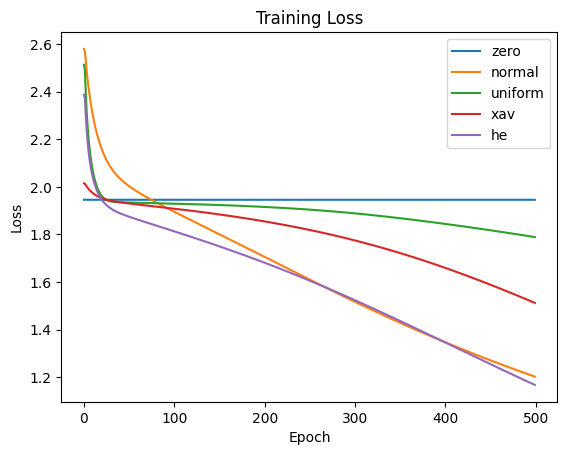

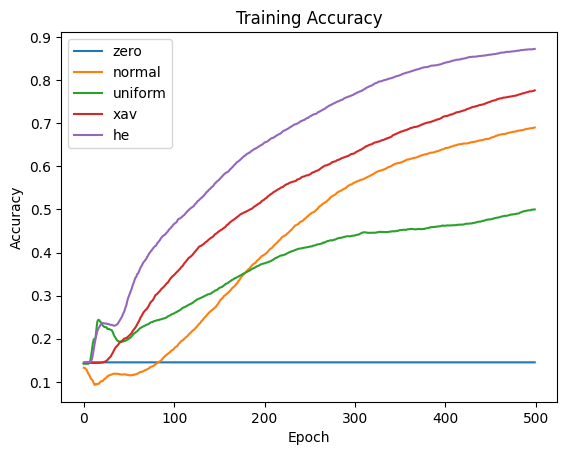

In [19]:
def experiment(hidden_sizes, features, classes, init_method, epoch, lr, beta):
    """ Initialises, trains and finds the loss and accuracy of a network given the hyperparameters.
    
    Args:        
        hidden_sizes: number of neurons in the hidden layers as an array
        features: number of features per sample (input size)
        classes: number of classes available to predict (output size)
        init_method: method used to initialise the weights and biases of the Linear layers

    Returns:
        losses: losses after each epoch as list
        accs: accuracies after each epoch as list
        net: the ANN instance used as the model for this experiment
            
    """
    # initialise new network
    layers = [features] + hidden_sizes + [classes]
    net = Network(layers, init_method)
    # initialise loss and accuracy arrays
    losses = []
    accs = []
    # train the network and add losses and accuracies at each epoch
    for i in range(epoch):
        epoch_loss, epoch_acc = train(net, train_x, train_y, Loss, lr, beta)
        losses.append(np.mean(epoch_loss))
        accs.append(np.mean(epoch_acc))
    return (losses, accs, net)

# run experiments
losses_zero, accs_zero, _ = experiment([8], 10, 7, 0, 500, 0.1, 0.8)
losses_normal, accs_normal, _ = experiment([8], 10, 7, 1, 500, 0.1, 0.8)
losses_uniform, accs_uniform, _ = experiment([8], 10, 7, 2, 500, 0.1, 0.8)
losses_xav, accs_xav, _ = experiment([8], 10, 7, 3, 500, 0.1, 0.8)
losses_he, accs_he, _ = experiment([8], 10, 7, 4, 500, 0.1, 0.8)


# loss
plt.figure()
plt.plot(losses_zero, label = 'zero')
plt.plot(losses_normal, label = 'normal')
plt.plot(losses_uniform, label = 'uniform')
plt.plot(losses_xav, label = 'xav')
plt.plot(losses_he, label = 'he')
plt.legend()
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# accuracy
plt.figure()
plt.plot(accs_zero, label = 'zero')
plt.plot(accs_normal, label = 'normal')
plt.plot(accs_uniform, label = 'uniform')
plt.plot(accs_xav, label = 'xav')
plt.plot(accs_he, label = 'he')
plt.legend()
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()


<div>

Every initialisation had an increase in accuracy over epochs except the zero-initialisation, with Xavier/He initialisation working most optimally. The zero-initialisation did not improve in performance due to the neurons in every layer collapsing into one. <br> This happens because very neuron has the exact same weights and biases, essentially producing the same output. Therefore, this model can work only as well as a corresponding model with just one neuron in each layer.
Xavier and He initialisation reached the highest accuracy and at the steepest gradient. This is because while the normal initialisation doesn't take the in and out degree of the nodes, which can explode/vanish the gradients, He and Xavier do and therefor the learning is stable.

</div>

### 1.4 Optimization

#### Question 11

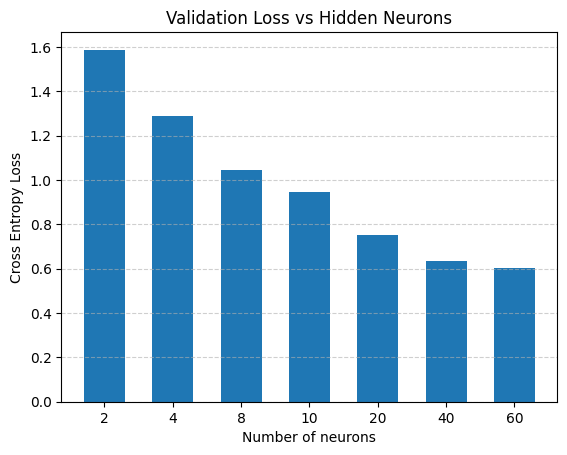

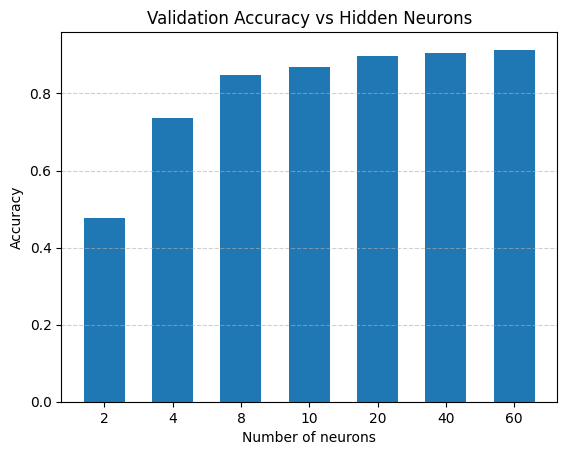

In [20]:
def evaluate(net, inputs, labels, criterion):
    preds = net.forward(inputs)
    loss, _ = criterion(labels, preds)
    pred_classes = np.argmax(preds, axis=1) + 1
    acc = np.mean(pred_classes == labels)
    return loss, acc

def evaluate_experiment(hidden_size):
    _, _, net = experiment([hidden_size], 10, 7, 3, 800, 0.1, 0.8)

    return evaluate(net, val_x, val_y, Loss)

sizes = [2, 4, 8, 10, 20, 40, 60]
results_loss = {h: [] for h in sizes}
results_acc  = {h: [] for h in sizes}

for _ in range(10):
    for s in sizes:
        _, _, net = experiment([s], 10, 7, 3, 800, 0.1, 0.8)
        loss,acc = evaluate(net, val_x, val_y, Loss)
        results_loss[s].append(loss)
        results_acc[s].append(acc)
    
avg_losses = [np.mean(results_loss[h]) for h in sizes]
avg_accs   = [np.mean(results_acc[h])  for h in sizes]



x = np.arange(len(sizes))

plt.figure()
plt.bar(x, avg_losses, width=0.6)
plt.xticks(x, sizes)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.title("Validation Loss vs Hidden Neurons")
plt.xlabel("Number of neurons")
plt.ylabel("Cross Entropy Loss")

plt.show()


plt.figure()
plt.bar(x, avg_accs, width=0.6)
plt.xticks(x, sizes)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.title("Validation Accuracy vs Hidden Neurons")
plt.xlabel("Number of neurons")
plt.ylabel("Accuracy")

plt.show()

<div>

With one single layer, there is a plato in the accuracy after 20 neurons. With a layer of 20 neurons, it reaches 90% accuracy with little gain when doubling. The initial increase in accuracy comes from the layer's increased ability to capture the complexity of the dataset. However, since our data only contains 10 features with 7 output classes, the plato is seen quite quickly as the complexity of the dataset itself is not too high.

</div>

#### Question 12

Accuracy after 800 epochs: 0.9068582863380026


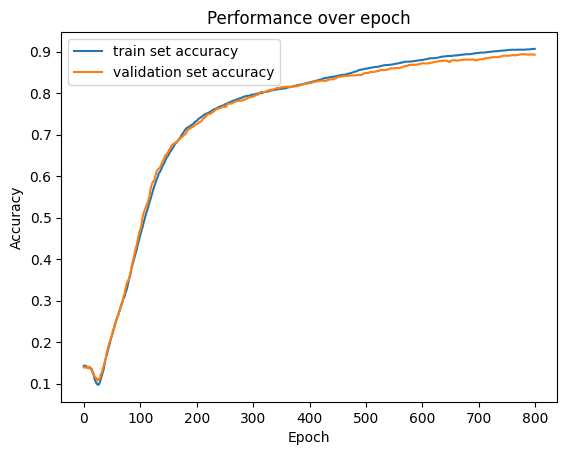

In [31]:
# chosen hidden layer neuron count = 20
hidden_size = 20
net = Network([10, hidden_size, 7], 3)

# initialise arrays to keep track of accuracy over epochs
results_train_acc = []
results_val_acc = []

# train network
for _ in range(800):
    _, train_acc = train(net, train_x, train_y, Loss, 0.1, 0.8)
    _, val_acc = evaluate(net, val_x, val_y, Loss)
    
    # append accuracies to respective arrays
    results_train_acc.append(train_acc)
    results_val_acc.append(val_acc)

final_val_acc = results_train_acc[len(results_train_acc) - 1]
final_val_acc_string = f"Accuracy after 800 epochs: {final_val_acc}"
print(final_val_acc_string)


# accuracy
plt.figure()
plt.plot(results_train_acc, label = 'train set accuracy')
plt.plot(results_val_acc, label = 'validation set accuracy')
plt.legend()
plt.title("Performance over epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()


<div>

Use 20 neurons as that's where the plateau started. One layer.

</div>

### 1.5 Evaluation

#### Question 13

Accuracy after 800 epochs: 0.8956743002544529


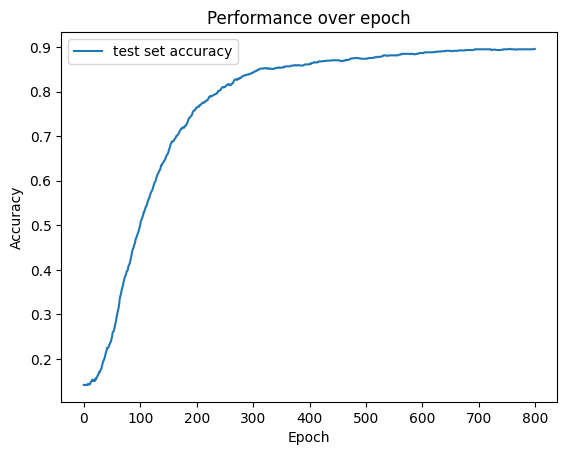

In [ ]:
hidden_size = 20
optimal_net = Network([10, hidden_size, 7], 3)

test_accs = []

# train final network for test set
for _ in range(800):
    train(optimal_net, train_x, train_y, Loss, 0.1, 0.8)
    _, test_acc = evaluate(optimal_net, test_x, test_y, Loss)
    
    test_accs.append(test_acc)

final_test_acc = test_accs[len(test_accs) - 1]
final_test_acc_string = f"Accuracy after 800 epochs: {final_test_acc}"
print(final_test_acc_string)

# accuracy plotting
plt.figure()
plt.plot(test_accs, label = 'test set accuracy')
plt.legend()
plt.title("Performance over epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()


<div>

The accuracy of the test set is 89.6% after 800 epochs of gradient descent, which is +-1% lower than that of the validation set. This is because the validation set is used implicitly to tune the hyperparameters, hence the validation set becomes slightly more optimistic in terms of performance. The difference of 1% shows that the generalisation of the model is adequate and there is not much overfitting.
</div>

#### Question 14

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer 20re._

</div>

#### Question 15

In [ ]:
preds = optimal_net.forward(unknown) 
pred_classes = np.argmax(preds, axis=1) + 1
# not graded anymore but will still leave the predictions

<div>

Due to issues with the Vocareum autograder, we could not get a value for the tests.

</div>

### 1.6 Scikit-learn

#### Question 16

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer 20re._

</div>

#### Question 17

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer 20re._

</div>

In [ ]:
# create txt with predictions
np.savetxt("01_classes.txt", pred_classes, fmt='%d', delimiter=",", newline=",")
# remove last comma
with open("01_classes.txt", "w") as f:
    f.write(",".join(map(str, pred_classes)))

### 1.7 Reflection

#### Question 18

<div style="background-color:#f1be3e">

_Write your answer 20re._

</div>

#### Question 19

<div style="background-color:#f1be3e">

_Write your answer 20re._

</div>

### 1.8 Pen and paper

#### Question 20

<div style="background-color:#f1be3e">

_Write your answer 20re. You can also choose to simply include a photo of your solution._

</div>

#### Question 21

<div style="background-color:#f1be3e">

_Write your answer 20re. You can also choose to simply include a photo of your solution._

</div>

### 1.9 Division of work

#### Question 22

<div>


|          Component          |  Junhan   |  Jack   |  Madhav  |  Ben  |
|-----------------------------|-----------|-----------|-----------|-----------|
| Code (design)               |     50%     |     50%     |     0%     |     0%     |
| Code (implementation)       |     40%     |     60%     |     0%     |     0%     |
| Code (validation)           |     50%     |     50%     |     0%     |     0%     |
| Experiments (execution)     |     100%     |     0%     |     0%     |     0%     |
| Experiments (analysis)      |     100%     |     0%     |     0%     |     0%     |
| Experiments (visualization) |     190%     |     0%     |     0%     |     0%     |
| Report (original draft)     |     60%     |     40%     |     0%     |     0%     |
| Report (reviewing, editing) |     0%     |     0%     |     50%     |     50%     |

</div>

### References

<div>

**If you made use of any non-course resources, cite them below.**

https://en.wikipedia.org/wiki/Perceptron#Steps (Used for weight adjustment in Perceptron class) <br>
https://ai.stackexchange.com/questions/7088/how-to-choose-an-activation-function-for-the-hidden-layers (Aided in choosing our activation function) <br>
https://medium.com/@hss245/choosing-hidden-layers-and-neurons-in-an-mlp-model-a-practical-guide-2777ecf3ab4b (Aided in choosing hidden layer size) <br>
https://www.parasdahal.com/softmax-crossentropy (Formula for dL/dy_hat given L is cross entropy loss and y_hat is softmax output)


</div>